In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
import gc

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5
G_lo = 20.0

In [4]:
nthreads = 18

In [5]:
# cosmology 1
h=0.6844
Omega_m = 0.302

# cosmology 2
Omega_m_quaia = 0.343
h_quaia = 0.674

In [6]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [7]:
H0 = h*100 * u.km/u.s/u.Mpc
rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

H0_quaia = h_quaia*100 * u.km/u.s/u.Mpc
rbins_Mpc_quaia = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_quaia))

In [8]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

In [9]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

In [10]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [11]:
pimax = 80 # 40 # 5000.0 # 40.0

In [12]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [13]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
z_array = range(len(z_bins)-1)
mask = 0.5

In [14]:
Omega_c = 0.2513
Omega_b = 0.048
Omega_m_planck = Omega_c+Omega_b
cosmo = ccl.Cosmology(Omega_c=Omega_m*Omega_c/Omega_m_planck, Omega_b=Omega_m*Omega_b/Omega_m_planck,
                          h=h, n_s=0.95, sigma8=0.8)
cosmo_quaia = ccl.Cosmology(Omega_c=Omega_m_quaia*Omega_c/Omega_m_planck, Omega_b=Omega_m_quaia*Omega_b/Omega_m_planck,
                          h=h_quaia, n_s=0.95, sigma8=0.766)
# a = a_median(tab_datahi_mask_zbin0)

In [15]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [16]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
colors = [orange, green]

In [17]:
labels = ['Planck18', 'Quaia23']

In [18]:
h = 0.6774
Delta = 200
delta_c = 1.686

In [23]:
cosmo_default = ccl.Cosmology(Omega_b=0.0486, Omega_c=0.2589, h=h, n_s=0.9667, sigma8=0.8159)
hmf = ccl.halos.MassFuncTinker10()

## Define functions

In [24]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [25]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [26]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_default):
    
    sigma = cosmo.sigmaM(M/cosmo['h'], a = a)
   
    return delta_c/sigma

In [27]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_default, hmf = hmf):

    nm = hmf(cosmo, quaia.recenter(bins)/cosmo['h'], a)/cosmo['h']**3
    n_g = nm/(quaia.recenter(bins)*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_default, mod = False):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo)
    n_g = np.trapz(n_g, quaia.recenter(bins))
    dm = np.diff(bins) 
    dn_dm = nm/(quaia.recenter(bins)*np.log(10))

    b1_E_tinker = b1_E_func(nu(quaia.recenter(bins), a = a, cosmo = cosmo), mod = mod)
    # b1_L_tinker = b1_L_func(b1_E_tinker)
    
#     b2_E_lazeyras = b2(b1_E_tinker)
#     b2_L_lazeyras = b2_L(b2_E_lazeyras, b1_L_tinker) 
    
#     bs2_L_abidi = bs2_L_func(bins)
#     bs2_lazeyras = bES_s2_L(b1_E_tinker)
#     bs2_L_lazeyras = bs2_L(bs2_lazeyras, b1_L_tinker)

#     b3_E_tinker = b3(b1_E_tinker)
#     b3_L_lazeyras = b3_L(b1_L_tinker, b2_L_lazeyras)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    # bias_params = [b1_L_tinker, b2_L_lazeyras, bs2_L_abidi, bs2_L_lazeyras, b3_L_lazeyras]
    
    return bias_function(n_g, integrand, b1_E_tinker, bins), n_g

In [28]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al

# def b1_L_func(b1_E):
#     return b1_E-1 

# def bs2_L_func(bins): # eq 5.1 in Abidi et al
#     return -0.5*(recenter(bins)/(4e14))**0.8

# def bES_s2_L(b1):
#     return 0.524 - 0.547*b1 + 0.046*b1**2 # eq. 4.2 in lazeyras et al
    
def bias_function(n_g, integrand, b, bins):
    return 1/n_g*np.trapz(integrand*b, quaia.recenter(bins))

In [29]:
def cf_2h(bins, n_m, a, cosmo, cf_matter):
    
    b_q, n_g = bias(bins, n_m, a, cosmo)
    return b_q**2*cf_matter, b_q

# Implement halo model
## Plot HOD: $<N(M)>= \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$

In [30]:
bins_offset = 0.1
bins = np.logspace(10, 15+bins_offset, 50)

In [31]:
fduty = 4.5/100
n_m=np.zeros(np.shape(quaia.recenter(bins)))
n_m[quaia.recenter(bins)>=10**12.8]=fduty

<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_16323/3540984491.py:3: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


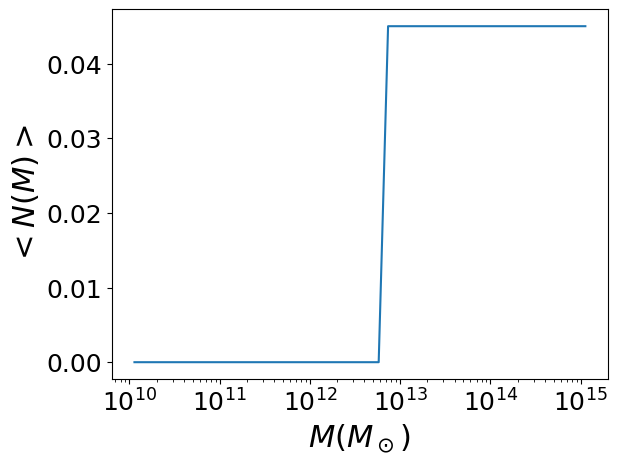

In [32]:
plt.plot(quaia.recenter(bins), n_m)
plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel('$<N(M)>$')
plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [33]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

cf_zbin_percentile, cf_matter_zbin_percentile = {label: [] for label in labels}, {label: [] for label in labels}
yerr_cf, b_cf = {label: [] for label in labels}, {label: [] for label in labels}
a_zbin, b_cf_q = {label: [] for label in labels}, {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask*100, percentile = True)
        
        # quasar correlation function
        cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                   rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i], error = True)
        cf_zbin_percentile[labels[i]].append(cf)

        # scale factor
        a = a_median(tab_datahi_mask_zbin0)
        a_zbin[labels[i]].append(a)
        
        # matter correlation function
        H0 = h_array[i]*100 * u.km/u.s/u.Mpc
        rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
        cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
        cf_matter_zbin_percentile[labels[i]].append(cf_matter)
        
        # effective bias 
        b = np.sqrt(cf/cf_matter)
        b_cf[labels[i]].append(b)
        
        # yerr
        yerr=(1+cf)/np.sqrt(qq)
        yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
        yerr_cf[labels[i]].append(yerr)
        
        # qso bias
        b_cf_q[labels[i]].append(b_qso(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_16323/2346443329.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_16323/2346443329.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_16323/2346443329.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_16323/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_16323/2346443329.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_16323/2346443329.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_16323/2346443329.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_16323/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_16323/2346443329.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_16323/2346443329.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_16323/2346443329.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_16323/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_16323/2346443329.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_16323/2346443329.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_16323/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_16323/2346443329.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_16323/2346443329.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_16323/2346443329.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_16323/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Measure $\xi(s)$ and calculate the two-halo term: $\xi_{2 h}(r) \approx\left[n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle b_h(M)\right]^2 \xi_m(r)$
###  Implement Poisson error bars: $\Delta \xi(s)=\begin{cases}\frac{1+\xi(s)}{\sqrt{DD(s)}} & \xi(s)\geq 0 \\ \sqrt{\frac{1+\xi(s)_\mathrm{model}}{D R}} & \xi(s)<0\end{cases}$ 

<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16323/413720331.py:26: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])


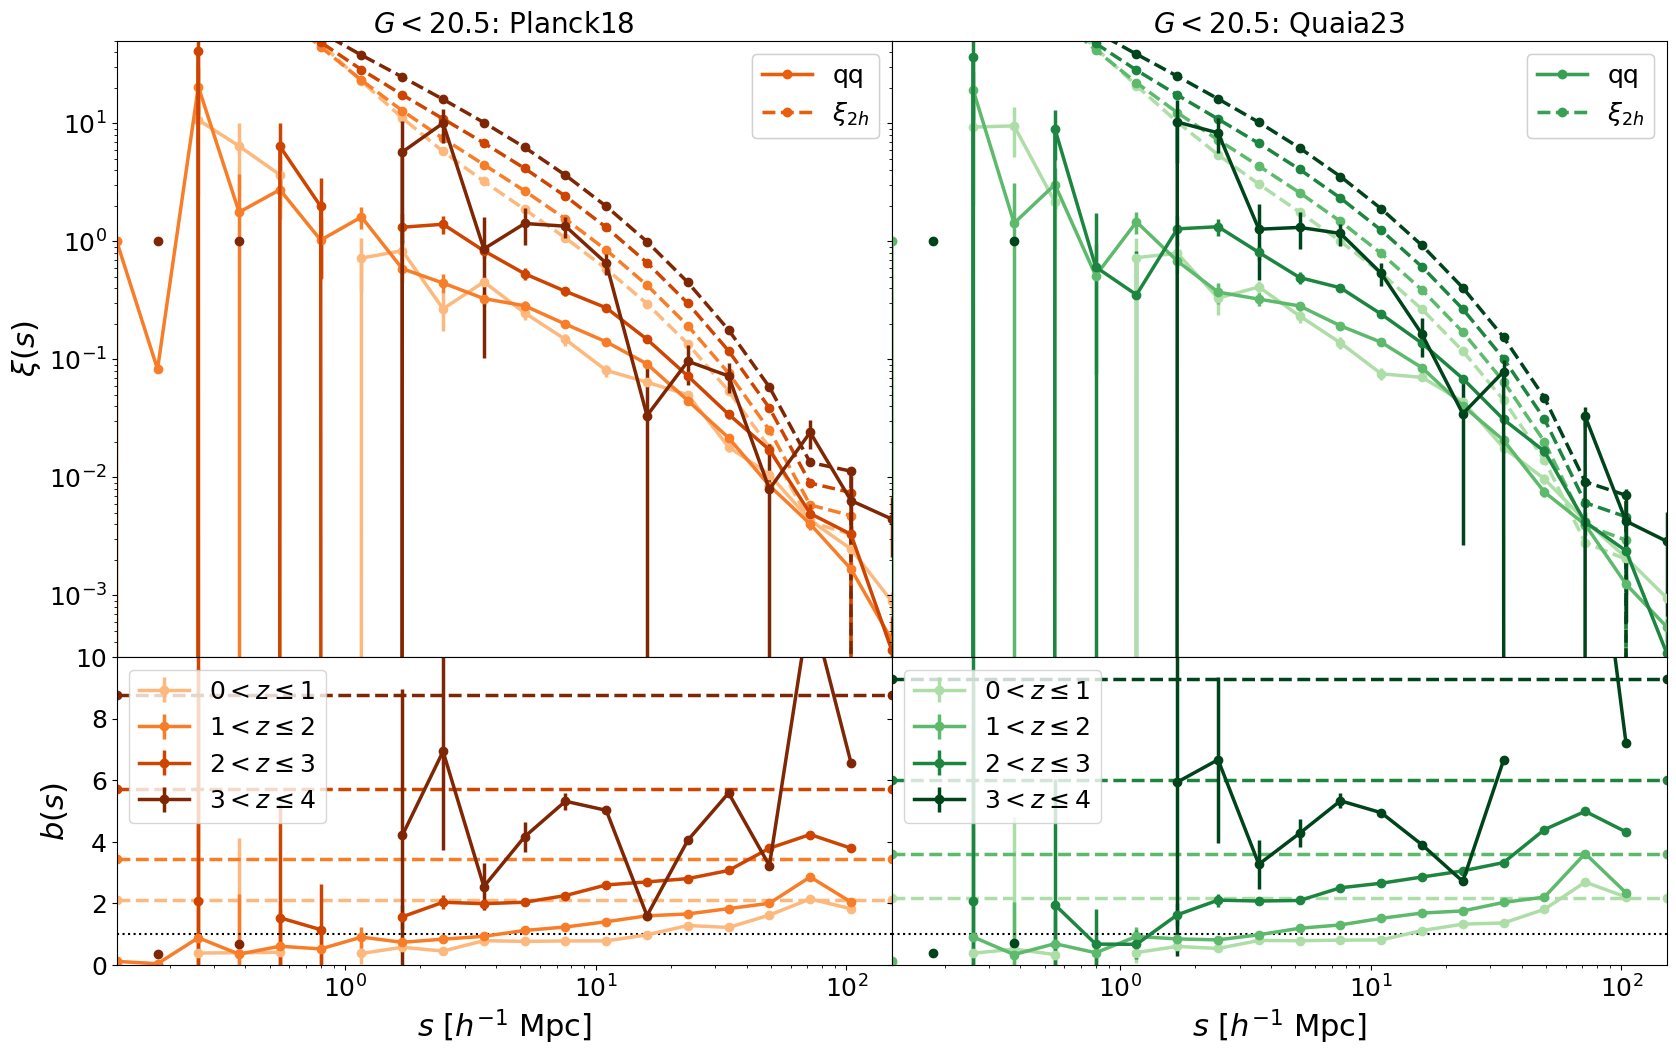

In [34]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        # b = np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j])
        # ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        # yerr = (1+cf_zbin_percentile[labels[i]][j])/np.sqrt(qq_cf[labels[i]][j])
        # yerr[cf_zbin_percentile[labels[i]][j]<0]=np.sqrt((1+b**2*cf_matter_zbin_percentile[labels[i]][j])/ #https://arxiv.org/abs/1603.04849
                                                         # qr_cf[labels[i]][j])[cf_zbin_percentile[labels[i]][j]<0] 
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j], 
                     yerr = yerr_cf[labels[i]][j])
        # ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], 
        #          linestyle = '--', alpha = 0.5)
        cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, marker = 'o', label = r'\xi_2h}',
                 color = cmaps[i][j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])
        # ax2.errorbar(quaia.recenter(rbins), b_cf_q[labels[i]][j], linewidth = 2.5, marker = 'o', 
                     # label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])
        ax2.axhline(b_q, linewidth = 2.5, marker = 'o', color = cmaps[i][j], linestyle = '--')

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = ':', color = 'black')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16323/2305572897.py:23: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])
/tmp/ipykernel_16323/2305572897.py:30: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


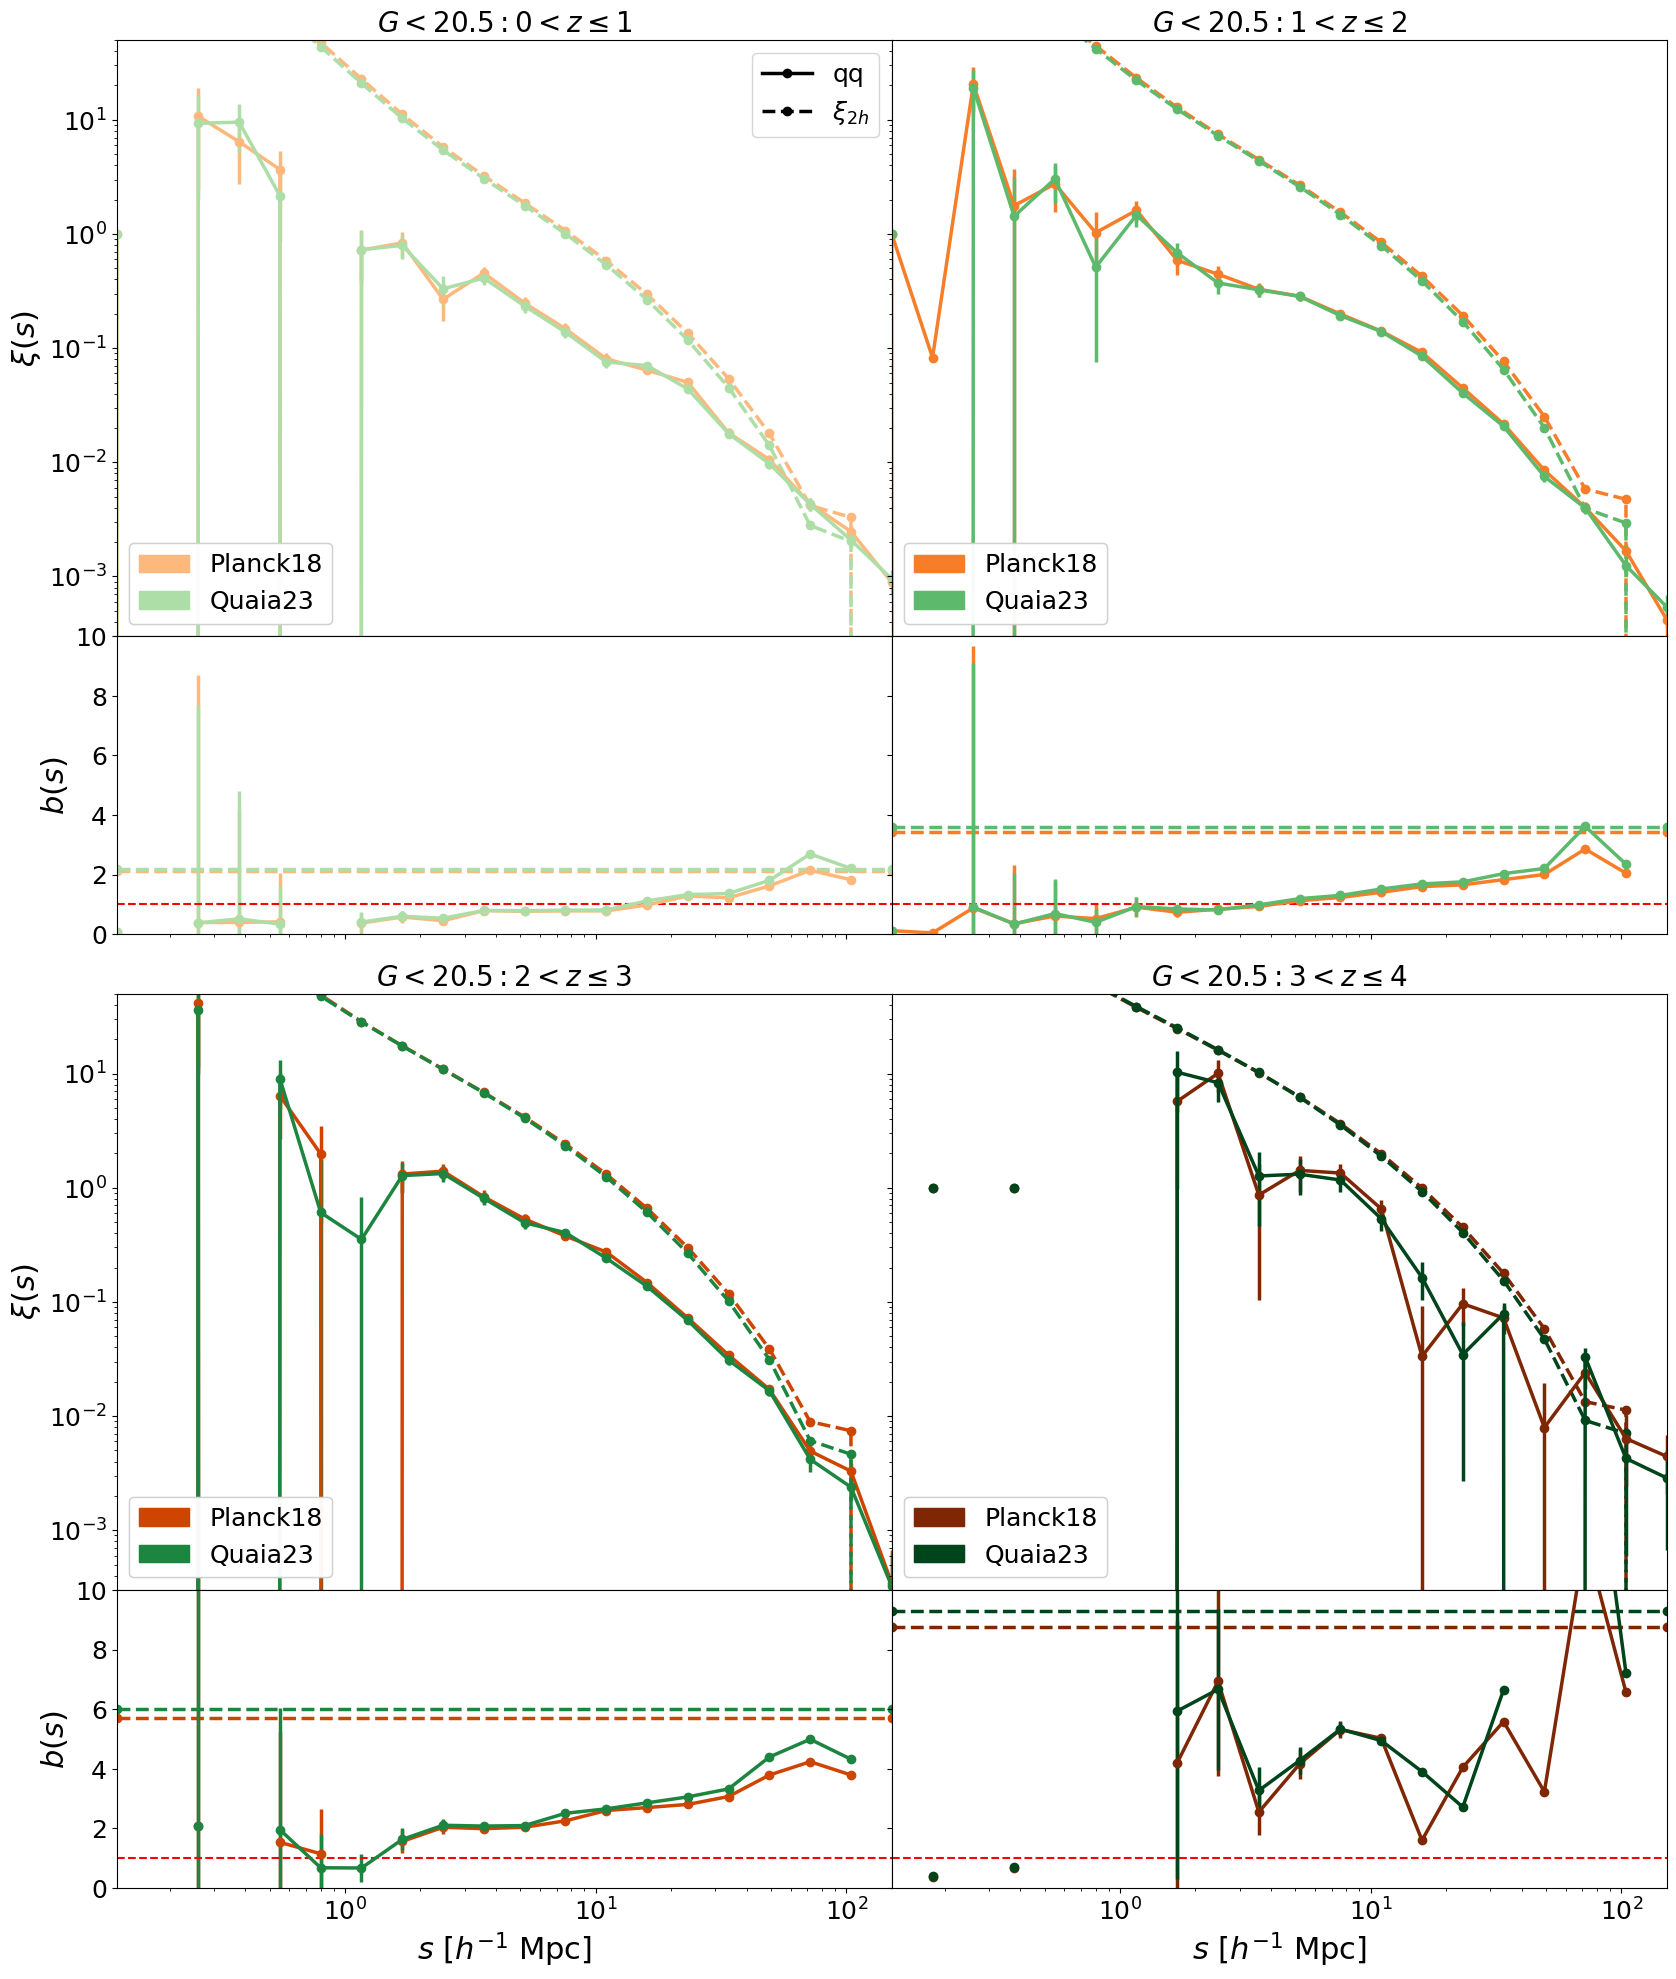

In [35]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

# labels_cf = ['qq', r'$\xi_{2h}$']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j],
                    yerr = yerr_cf[labels[i]][j])
        # ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], 
        #          linestyle = '--')
        cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, marker = 'o', label = r'\xi_2h}',
                 color = cmaps[i][j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])
        # ax2.errorbar(quaia.recenter(rbins), bias(cf_zbin_percentile[labels[i]][j], cf_matter_zbin_percentile[labels[i]][j], 
        #                                         ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
        #             label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])
        ax2.axhline(b_q, linewidth = 2.5, marker = 'o', color = cmaps[i][j], linestyle = '--')

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

### Try a galactic latitude mask

In [45]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']
labels_cf = ['qq', r'$\xi_{2h}$']
for i in range(len(Omega_m_array)):
        
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    
    for b in [10, 20, 30, 40, 50]:
        
        for j in z_array:
            
            tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], mask_type = 'b', b = b,
                                                                                             bins = [z_bins], tab_gcat_type = 'data',
                                                                                             method = ['minmax'], fac_rand = 25,
                                                                                             n_bins = [None])

            # quasar correlation function
            cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                       rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i], error = True)
            np.save('../results/cf_{}_b{}_z{}'.format(labels[i],b,j), cf)
            del tab_randhi_mask_zbin0, key_zbin0
            gc.collect()
            
            # scale factor
            a = a_median(tab_datahi_mask_zbin0)
            np.save('../results/a_{}_b{}_z{}'.format(labels[i],b,j), a)
            del tab_datahi_mask_zbin0
            gc.collect()
            
            # matter correlation function
            cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
            np.save('../results/cf_matter_{}_b{}_z{}'.format(labels[i],b,j), cf_matter)

            # effective bias 
            b_eff = np.sqrt(cf/cf_matter)
            np.save('../results/b_eff_{}_b{}_z{}'.format(labels[i],b,j), np.sqrt(cf/cf_matter))
            
            # yerr
            yerr=(1+cf)/np.sqrt(qq)
            yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
            np.save('../results/yerr_{}_b{}_z{}'.format(labels[i],b,j), yerr)
            del yerr, b_eff, qq, qr
            gc.collect()
            
            # qso bias
            np.save('../results/b_qso_{}_b{}_z{}'.format(labels[i],b,j), b_qso(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))
            del cf, cf_matter, a
            gc.collect()

G20.5_zmin0.0zmax1.0: 0.02              318263 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_9156/4120752242.py:47: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_9156/4120752242.py:48: RuntimeWarning: invalid value encountered in sqrt
  np.save('../results/b_eff_{}_b{}_z{}'.format(labels[i],b,j), np.sqrt(cf/cf_matter))
/tmp/ipykernel_9156/4120752242.py:51: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_9156/4120752242.py:52: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_9156/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45

G20.5_zmin1.0zmax2.0: 0.01              640759 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_9156/4120752242.py:47: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_9156/4120752242.py:48: RuntimeWarning: invalid value encountered in sqrt
  np.save('../results/b_eff_{}_b{}_z{}'.format(labels[i],b,j), np.sqrt(cf/cf_matter))
/tmp/ipykernel_9156/4120752242.py:51: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_9156/4120752242.py:52: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_9156/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45

G20.5_zmin2.0zmax3.0: 0.01              284132 vs 286508


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_9156/4120752242.py:47: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_9156/4120752242.py:48: RuntimeWarning: invalid value encountered in sqrt
  np.save('../results/b_eff_{}_b{}_z{}'.format(labels[i],b,j), np.sqrt(cf/cf_matter))
/tmp/ipykernel_9156/4120752242.py:51: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_9156/4120752242.py:52: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_9156/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45

G20.5_zmin2.0zmax3.0: 0.63              107434 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_9156/4120752242.py:47: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_9156/4120752242.py:48: RuntimeWarning: invalid value encountered in sqrt
  np.save('../results/b_eff_{}_b{}_z{}'.format(labels[i],b,j), np.sqrt(cf/cf_matter))
/tmp/ipykernel_9156/4120752242.py:51: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_9156/4120752242.py:52: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_9156/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45

G20.5_zmin3.0zmax4.0: 0.60              14252 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_9156/4120752242.py:47: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_9156/4120752242.py:48: RuntimeWarning: invalid value encountered in sqrt
  np.save('../results/b_eff_{}_b{}_z{}'.format(labels[i],b,j), np.sqrt(cf/cf_matter))
/tmp/ipykernel_9156/4120752242.py:51: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_9156/4120752242.py:52: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_9156/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16323/3696117984.py:22: SyntaxWarning: invalid escape sequence '\l'
  ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_16323/3696117984.py:43: SyntaxWarning: invalid escape sequence '\l'
  patch = [mpatches.Patch(color=cmaps[i][k], label = '${:.0f}<z \leq{:.0f}$'.format(k, k+1)) for k in z_array]


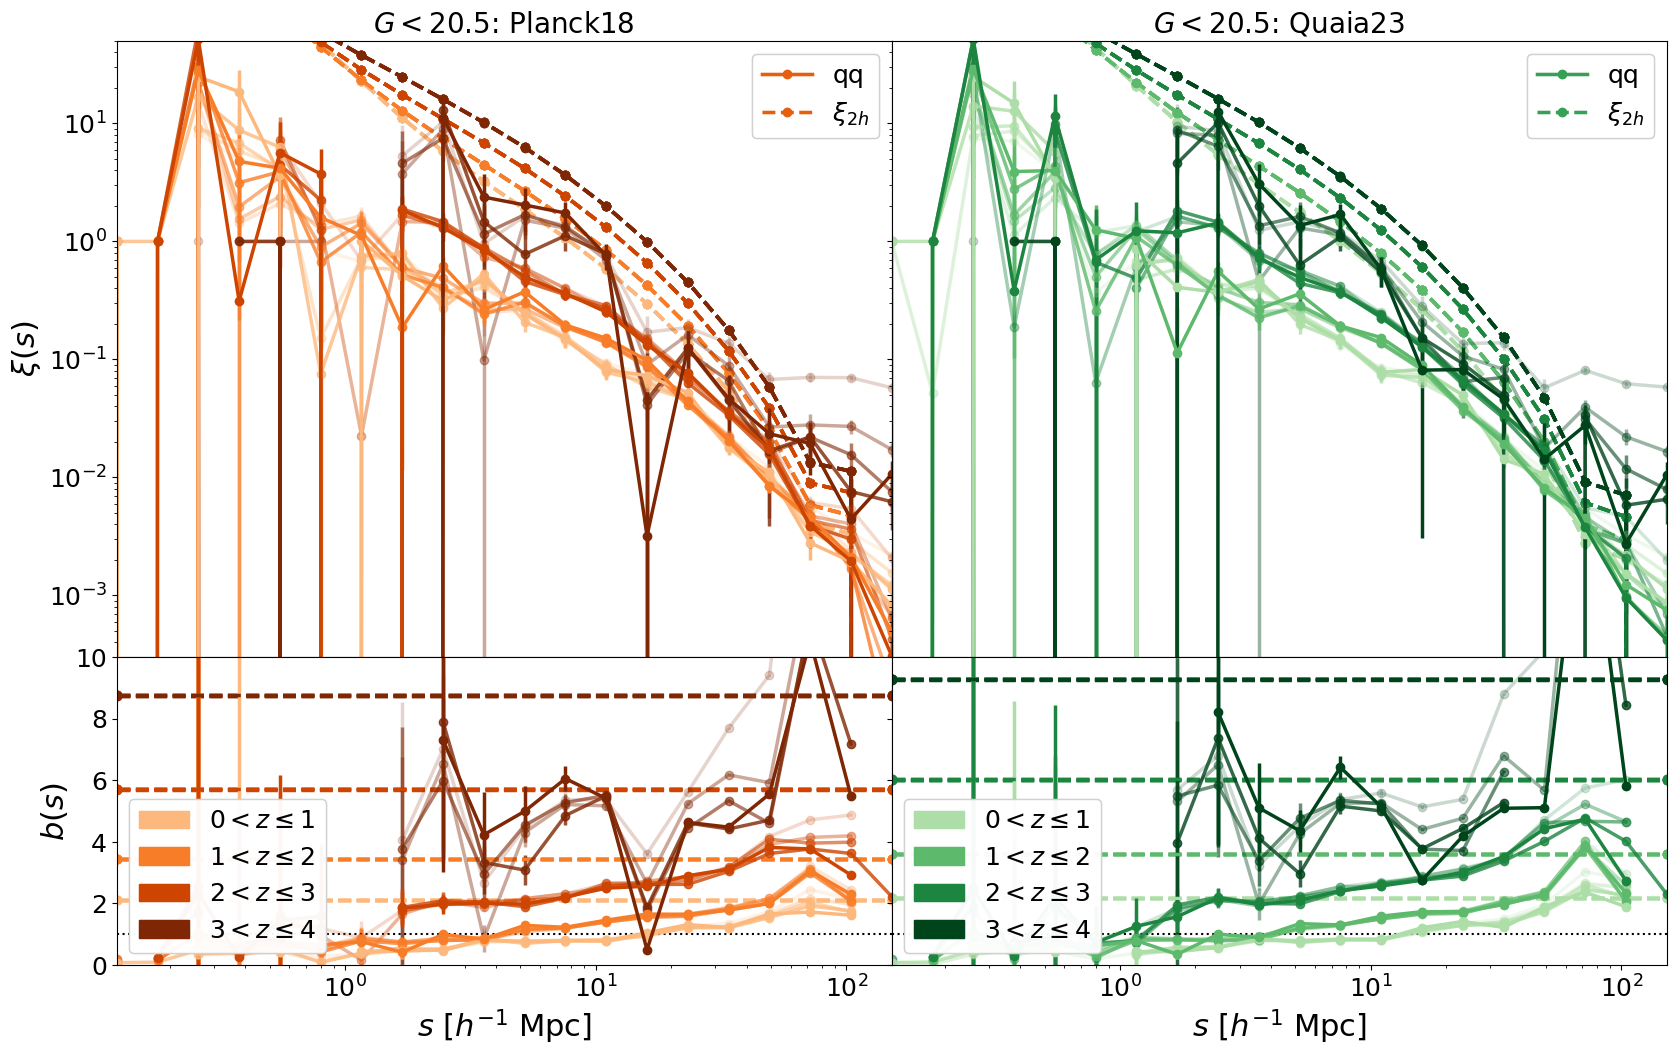

In [59]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

for i in range(len(Omega_m_array)):
        
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
        
    for b in [10, 20, 30, 40, 50]:
        
        for j in z_array:
            
            cf = np.load('../results/cf_{}_b{}_z{}.npy'.format(labels[i],b,j))
            cf_matter = np.load('../results/cf_matter_{}_b{}_z{}.npy'.format(labels[i],b,j))
            a = np.load('../results/a_{}_b{}_z{}.npy'.format(labels[i],b,j))
            yerr = np.load('../results/yerr_{}_b{}_z{}.npy'.format(labels[i],b,j))
            cf_2h_zbin, b_q = cf_2h(bins, n_m, float(a), cosmos[i], cf_matter)
            ax1.errorbar(quaia.recenter(rbins), cf, linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j], yerr = yerr, alpha = b/50)
            ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, marker = 'o', label = r'\xi_2h}', color = cmaps[i][j], linestyle = '--')

            b_eff = np.load('../results/b_eff_{}_b{}_z{}.npy'.format(labels[i],b,j))
            ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                         color = cmaps[i][j], yerr = yerr, alpha = b/50)
            ax2.axhline(b_q, linewidth = 2.5, marker = 'o', color = cmaps[i][j], linestyle = '--')

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = ':', color = 'black')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    # ax2.legend()
    
    patch = [mpatches.Patch(color=cmaps[i][k], label = '${:.0f}<z \leq{:.0f}$'.format(k, k+1)) for k in z_array]
    first_legend = ax2.legend(handles=patch, loc = 'lower left')
    ax2.add_artist(first_legend)

    if i == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:64: SyntaxWarning: invalid escape sequence '\l'
<>:64: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_30350/2299357805.py:64: SyntaxWarning: invalid escape sequence '\l'
  ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),


G20.5_zmin0.0zmax1.0: 0.02              318263 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_30350/2299357805.py:49: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_30350/2299357805.py:53: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_30350/2299357805.py:54: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


G20.5_zmin1.0zmax2.0: 0.01              640759 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_30350/2299357805.py:49: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_30350/2299357805.py:53: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_30350/2299357805.py:54: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_30350/2299357805.py:49: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_30350/2299357805.py:53: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_30350/2299357805.py:54: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


G20.5_zmin2.0zmax3.0: 0.63              107434 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_30350/2299357805.py:49: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_30350/2299357805.py:53: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_30350/2299357805.py:54: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


G20.5_zmin3.0zmax4.0: 0.60              14252 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_30350/2299357805.py:49: RuntimeWarning: invalid value encountered in sqrt
  b_eff = np.sqrt(cf/cf_matter)
/tmp/ipykernel_30350/2299357805.py:53: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_30350/2299357805.py:54: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


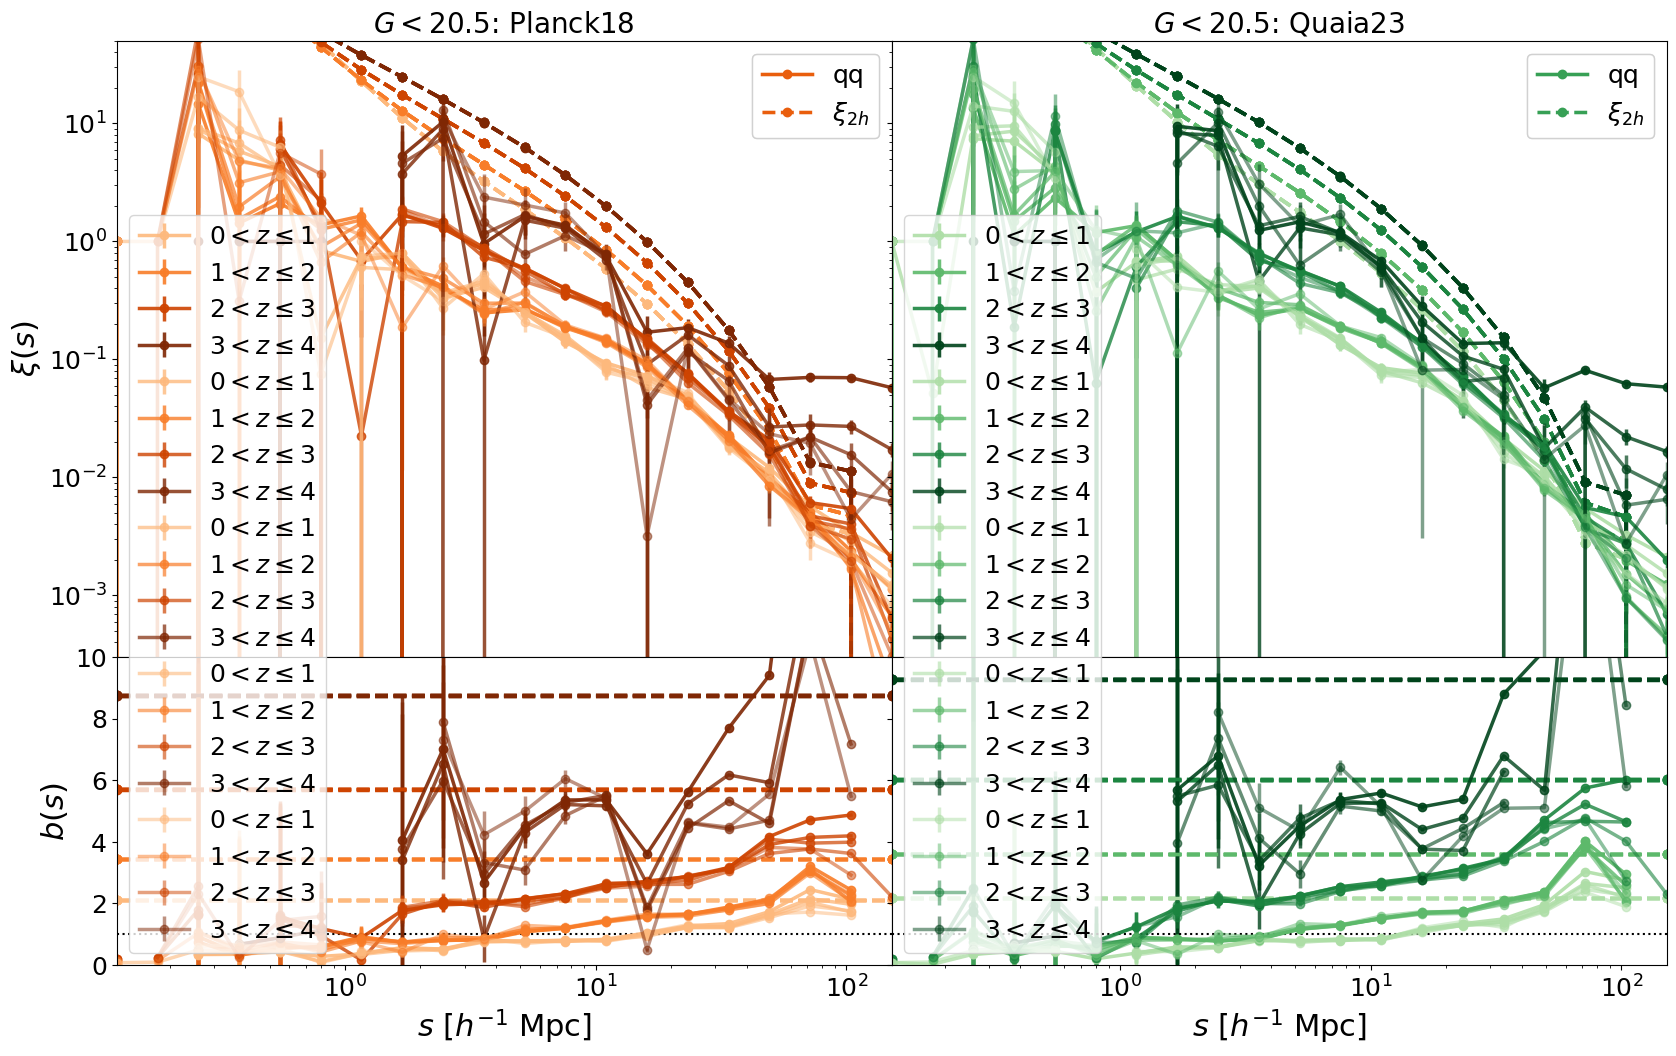

In [33]:
# Omega_m_array = [Omega_m, Omega_m_quaia]
# h_array = [h, h_quaia]
# cosmos = [cosmo, cosmo_quaia]
# linestyles = ['-', '--']

# cf_zbin_percentile_b = {label: {} for label in labels}
# yerr_cf_b, b_cf_b = {label: {} for label in labels}, {label: {} for label in labels}
# a_zbin_b, b_cf_q_b = {label: {} for label in labels}, {label: {} for label in labels}
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

# labels_cf = ['qq', r'$\xi_{2h}$']
for i in range(len(Omega_m_array)):
        
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
        
    for b in [10, 20, 30, 40, 50]:
        
        # cf_zbin_percentile_b[labels[i]][b]=[]
        # yerr_cf_b[labels[i]][b]=[]
        # b_cf_b[labels[i]][b]=[]
        # a_zbin_b[labels[i]][b]=[]
        # b_cf_q_b[labels[i]][b]=[]
        
        for j in z_array:
            
            tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], mask_type = 'b', b = b,
                                                                                             bins = [z_bins], tab_gcat_type = 'data',
                                                                                             method = ['minmax'], fac_rand = 25,
                                                                                             n_bins = [None])

            # quasar correlation function
            cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                       rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i], error = True)
            # cf_zbin_percentile_b[labels[i]][b].append(cf)

            # scale factor
            a = a_median(tab_datahi_mask_zbin0)
            # a_zbin_b[labels[i]][b].append(a)

            # matter correlation function
            H0 = h_array[i]*100 * u.km/u.s/u.Mpc
            rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
            cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
            # cf_matter_zbin_percentile[labels[i]][b].append(cf_matter)

            # effective bias 
            b_eff = np.sqrt(cf/cf_matter)
            # b_cf_b[labels[i]][b].append(b_eff)

            # yerr
            yerr=(1+cf)/np.sqrt(qq)
            yerr[cf<0]=np.sqrt((1+b_eff**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
            # yerr_cf_b[labels[i]][b].append(yerr)

            # # qso bias
            # b_cf_q_b[labels[i]][b].append(bias(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))
            
            ax1.errorbar(quaia.recenter(rbins), cf, linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j], yerr = yerr, alpha = 1-b/100)
            cf_2h_zbin, b_q = cf_2h(bins, n_m, a, cosmos[i], cf_matter)
            ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, marker = 'o', label = r'\xi_2h}', color = cmaps[i][j], linestyle = '--')

            ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                         color = cmaps[i][j], yerr = yerr, alpha = 1-b/100)
            ax2.axhline(b_q, linewidth = 2.5, marker = 'o', color = cmaps[i][j], linestyle = '--')

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = ':', color = 'black')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()

    if i == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23286/413720331.py:26: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])


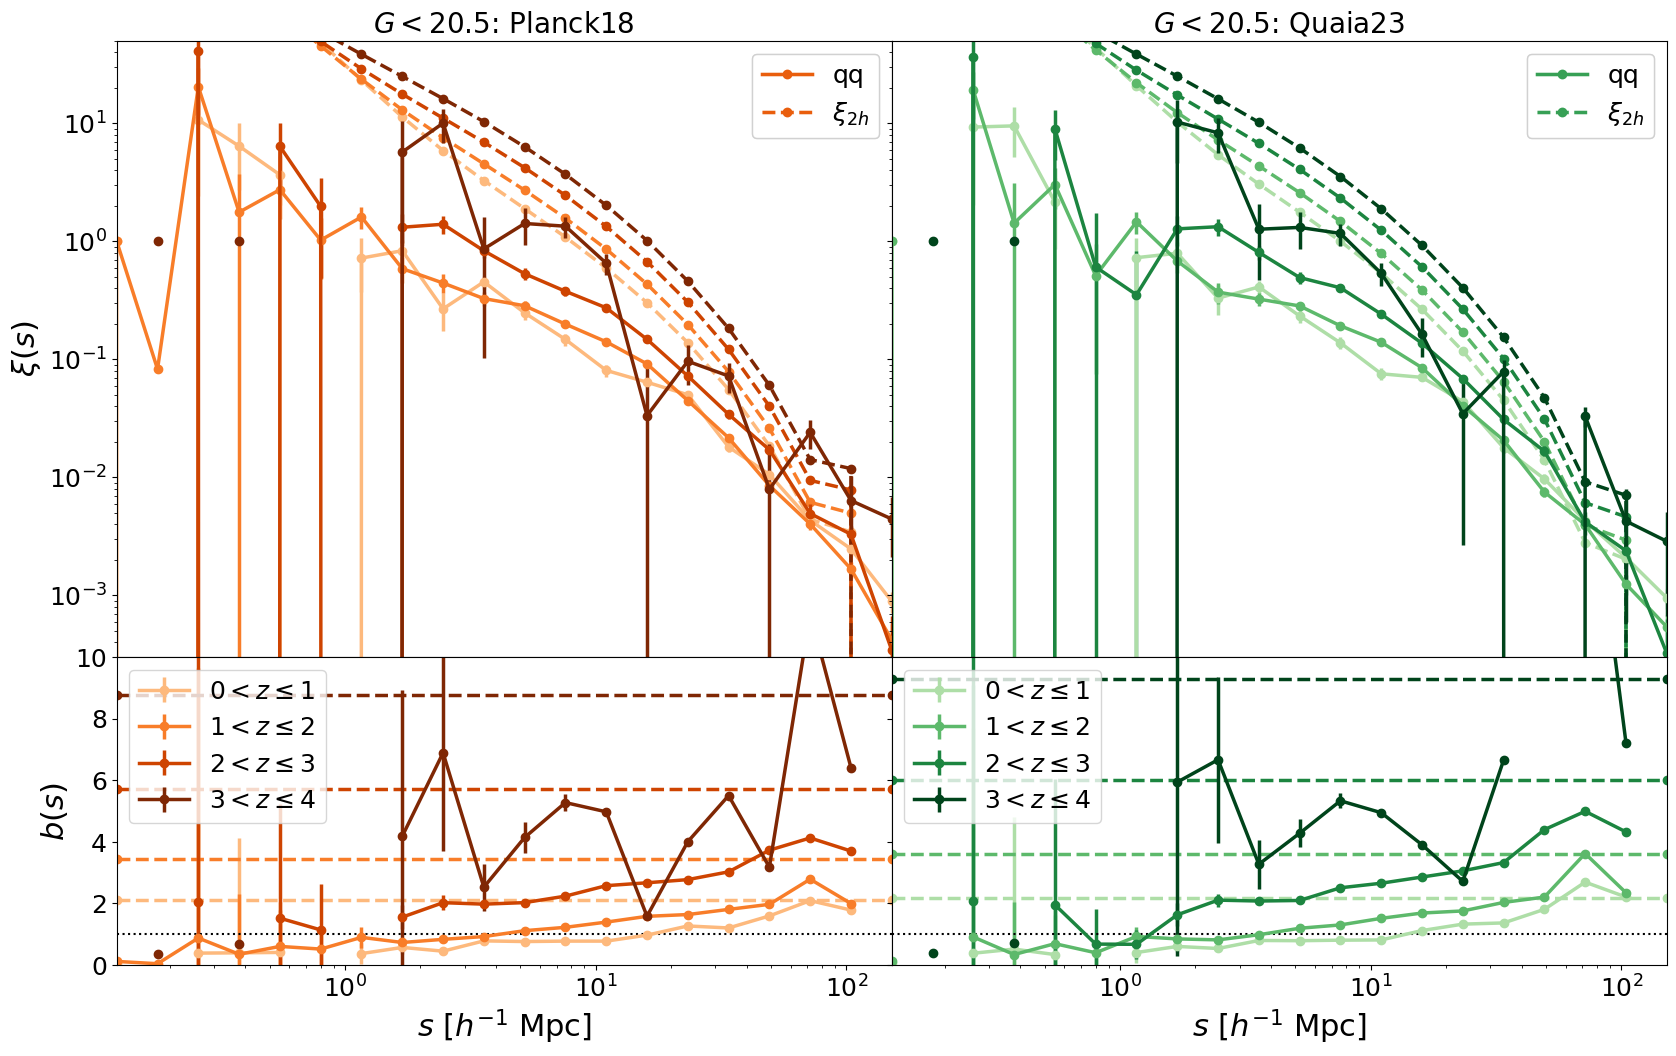

In [40]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        # b = np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j])
        # ax1.plot(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j])
        # yerr = (1+cf_zbin_percentile[labels[i]][j])/np.sqrt(qq_cf[labels[i]][j])
        # yerr[cf_zbin_percentile[labels[i]][j]<0]=np.sqrt((1+b**2*cf_matter_zbin_percentile[labels[i]][j])/ #https://arxiv.org/abs/1603.04849
                                                         # qr_cf[labels[i]][j])[cf_zbin_percentile[labels[i]][j]<0] 
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j], 
                     yerr = yerr_cf[labels[i]][j])
        # ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], 
        #          linestyle = '--', alpha = 0.5)
        cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, marker = 'o', label = r'\xi_2h}',
                 color = cmaps[i][j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])
        # ax2.errorbar(quaia.recenter(rbins), b_cf_q[labels[i]][j], linewidth = 2.5, marker = 'o', 
                     # label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_cf[labels[i]][j])
        ax2.axhline(b_q, linewidth = 2.5, marker = 'o', color = cmaps[i][j], linestyle = '--')

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = ':', color = 'black')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{w^{(s)}_{p,{\mathrm{qq}}}(r_p)}{w^{(r)}_{p,\mathrm{mm}}(r_p)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [ ]:
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

In [ ]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']
H0_array = [H0, H0_quaia]

wp_zbin_percentile, wp_matter_zbin_percentile = {label: [] for label in labels}, {label: [] for label in labels}
rpavg_zbin_percentile = {label: [] for label in labels}
yerr_wp, b_wp = {label: [] for label in labels}, {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:
    
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask)
        wp_zbin_i, rpavg_zbin_i, qq, qr = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, Om0 = Omega_m_array[i], h = h_array[i],
                                                          nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax, error = True)
        wp_zbin_percentile[labels[i]].append(wp_zbin_i)
        rpavg_zbin_percentile[labels[i]].append(rpavg_zbin_i)

        # version 3
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_array[i]))
        
        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmos[i], r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
        wp_matter_zbin_percentile[labels[i]].append(wp_matter_zbin_i)
        
        b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
        yerr=(1+wp_zbin_i)/np.sqrt(qq)
        yerr[wp_zbin_i<0]=np.sqrt((1+b**2*wp_matter_zbin_i)/qr)[wp_zbin_i<0] #https://arxiv.org/abs/1603.04849
        
        yerr_wp[labels[i]].append(yerr)
        b_wp[labels[i]].append(b)

In [ ]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr=yerr_wp[labels[i]][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j],
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(4, 25)
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                       title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(4, 25)
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                       title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j],
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(4, 25)
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                       title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(4, 25)
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

## Plot b evolution at a fixed scale
### $\xi(z)$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

for i in range(len(labels)):
    
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_cf[labels[i]][j][k] for j in z_array]

    # for j in z_array:
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
             linestyle = '--')

    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

### $w_p(s)$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rpbins)-10))

for i in range(len(labels)):
    
    wp_zbin_percentile_k = np.array([wp_zbin_percentile[labels[i]][j][k] for j in z_array])
    wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_wp[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, wp_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
             linestyle = '--')

    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
             color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_p({:.2f} h^{{-1}}$ Mpc) $[h^{{-1}}$ Mpc]'.format(quaia.recenter(rpbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rpbins)[k]))

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_cf[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
    # wp
    wp_zbin_percentile_k = np.array([wp_zbin_percentile[labels[i]][j][k] for j in z_array])
    wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_wp[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, wp_zbin_percentile_k/quaia.recenter(rpbins)[k], marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), linestyle = '--', yerr = yerr_k)
    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), linestyle = '--', yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)/r_p$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
ax1.set_title('$s,r_p = {:.2f}[h^{{-1}}$ Mpc]'.format(quaia.recenter(rbins)[k]))

patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi, w_p/r_p$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b$')

plt.show()

### Quasar bias

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

for i in range(len(labels)):
    
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_cf[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
             linestyle = '--')

    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

# Try the integration method
## Compute $\xi_{20}=3 / 20^3 \int_0^{20} \xi(s) s^2 d s$

In [ ]:
labels_cf = ['qq', 'mm']
cf_20={label: [] for label in labels}
cf_matter_20={label: [] for label in labels}
for i in range(len(Omega_m_array)):

    for j in z_array:

        # quasars
        bounds = quaia.recenter(rbins)<20
        integrand = np.copy(cf_zbin_percentile[labels[i]][j])*quaia.recenter(rbins)**2
        integrand[np.isnan(integrand)]=0
        cf_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))
        
        # matter
        integrand = np.copy(cf_matter_zbin_percentile[labels[i]][j])*quaia.recenter(rbins)**2
        integrand[np.isnan(integrand)]=0
        cf_matter_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(cf_20[labels[i]])/cf_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Compute $w_{p,20}=2 / 20^2 \int_0^{20} w_p(r_p) r_p d r_p$

In [ ]:
labels_cf = ['qq', 'mm']
wp_20={label: [] for label in labels}
wp_matter_20={label: [] for label in labels}
for i in range(len(Omega_m_array)):

    for j in z_array:

        # quasars
        bounds = np.array(rpavg_zbin_percentile[labels[i]][j])<20
        integrand = np.copy(wp_zbin_percentile[labels[i]][j])*rpavg_zbin_percentile[labels[i]][j]
        integrand[np.isnan(integrand)]=0
        wp_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], np.array(rpavg_zbin_percentile[labels[i]][j])[bounds]))
        
        # matter
        integrand = np.copy(wp_matter_zbin_percentile[labels[i]][j])*quaia.recenter(rpbins)
        integrand[np.isnan(integrand)]=0
        wp_matter_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rpbins)[bounds]))

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(wp_20[labels[i]])/wp_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(cf_20[labels[i]])/cf_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
    # wp
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(wp_20[labels[i]])/wp_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{20,qq}}}{\xi^{(r)}_\mathrm{20,mm}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(cf_20[labels[i]]), cf_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], 
    axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{w^{(s)}_{p,20,{\mathrm{qq}}}}{w^{(r)}_{p,20\mathrm{mm}}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(wp_20[labels[i]]), wp_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')
# ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(cf_20[labels[i]]), cf_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
    # wp
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(wp_20[labels[i]]), wp_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()